<a href="https://colab.research.google.com/github/kaymansrinivasan/Machine_Learning/blob/main/TimeSeriesHandsOnMarch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**dataset link** -- https://drive.google.com/file/d/1DHogc2Of_wcx3d1o3jmOTyIt6q46_L14/view

## prediction and forecast -- hw

# importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# warnings librarys -- filterwarnings("ignore")
# if there is any function/method which is soon going to be deprecated(function will not be available in upcoming version)

# Load the data

In [ ]:
df = pd.read_csv("/content/AirPassengers (1).csv")

In [ ]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Preprocessing

In [ ]:
rename_col = {
    "Month": "month",
    "#Passengers": "passengers"
}
df.rename(columns = rename_col, inplace = True)
df.head()

,month,passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
df.isnull().sum()

,0
month,0
passengers,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   month       144 non-null    object
 1   passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df['month'] = pd.to_datetime(df['month'])

In [ ]:
df.set_index("month", inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [ ]:
df.head()

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# Checking trends, seasonality, cyclicity -- stationarity

### 1. Line Plot

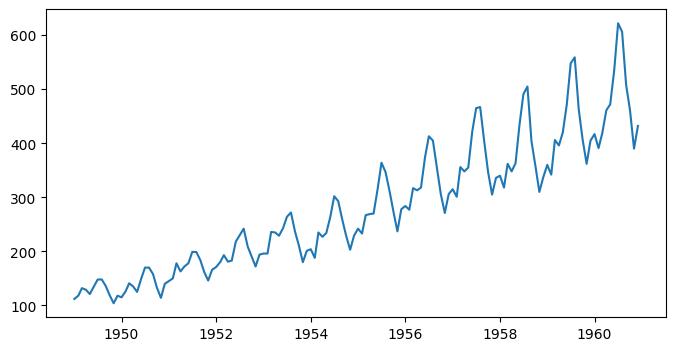

In [ ]:
plt.figure(figsize = (8, 4))
plt.plot(df)
plt.show()

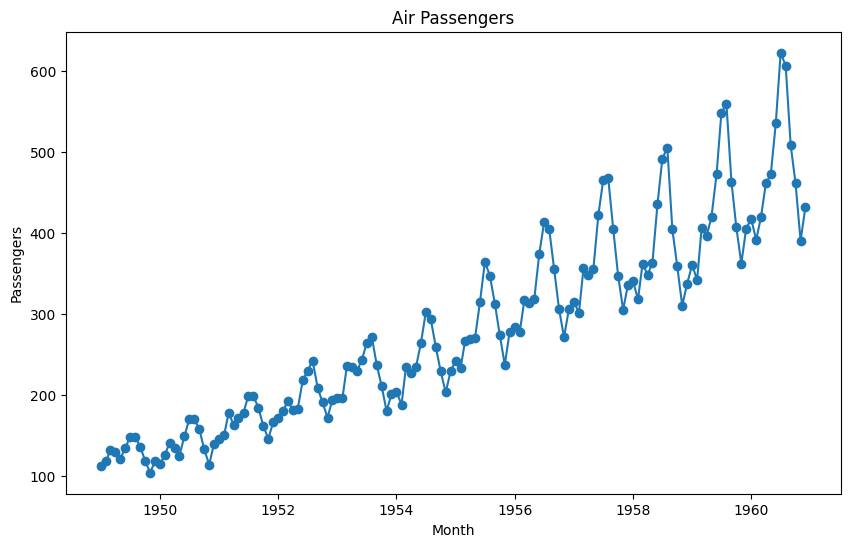

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df,marker='o')
plt.title('Air Passengers')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.show()

###2. Seasonal decompose

Figure(640x480)


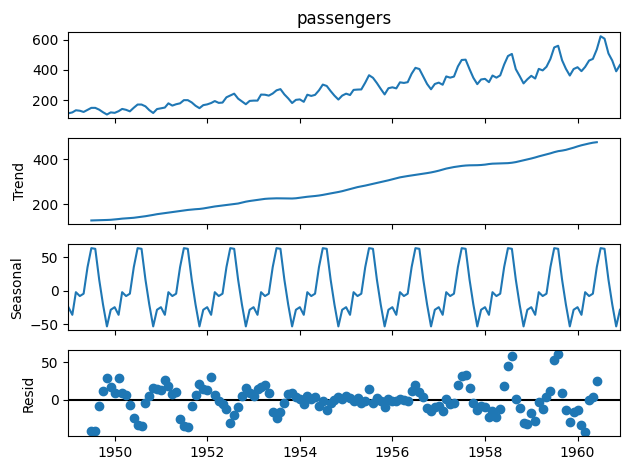

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose


decompose = seasonal_decompose(df['passengers'])
print(decompose.plot())

### 3. ADFuller Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
test_results = adfuller(df)
test_results

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
pval = test_results[1]
pval

np.float64(0.991880243437641)

In [ ]:
# Null Hypothesis: Data is not stationary
# Alternate Hypothesis: Data is stationary

In [ ]:
if pval>0.05:
  print("Data is not stationary.")
else:
  print("Data is stationary")

Data is not stationary.


In [ ]:
# Null hypothesis is true

# Convert data from non - stationary to stationary

In [ ]:
log_df = np.log(df)

In [ ]:
log_df.isnull().sum()

,0
passengers,0


[]

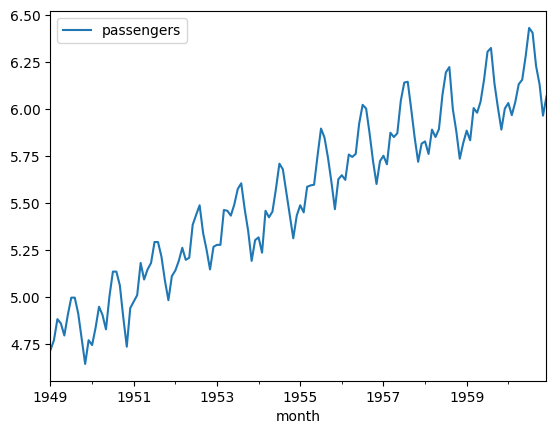

In [ ]:
log_df.plot()
plt.plot()

In [ ]:
mean = log_df.rolling(window = 12).mean()

In [ ]:
mean.head()

,passengers
month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN


In [ ]:
new_data = log_df - mean
new_data = new_data.dropna()
new_data

,passengers
month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


# Start with model building

In [ ]:
new_data.shape

(133, 1)

In [ ]:
# train and test

In [ ]:
133 * 0.8

106.4

In [ ]:
train = new_data.iloc[:106]['passengers']
test = new_data.iloc[106:]['passengers']

In [ ]:
train.head()

,passengers
month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142


In [ ]:
test.head()

,passengers
month,
1958-10-01,-0.045657
1958-11-01,-0.193762
1958-12-01,-0.110499
1959-01-01,-0.049241
1959-02-01,-0.106598


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

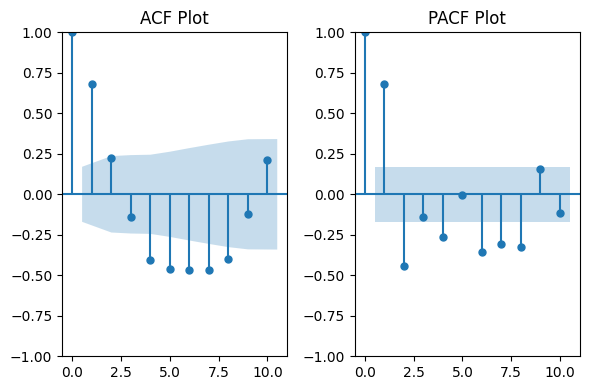

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (6, 4))
plot_acf(new_data, lags = 10, ax = axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(new_data,lags = 10, ax = axes[1])
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

In [ ]:
# arima -- p,d and q

# p -- AR model
# q -- MA model

##AR Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


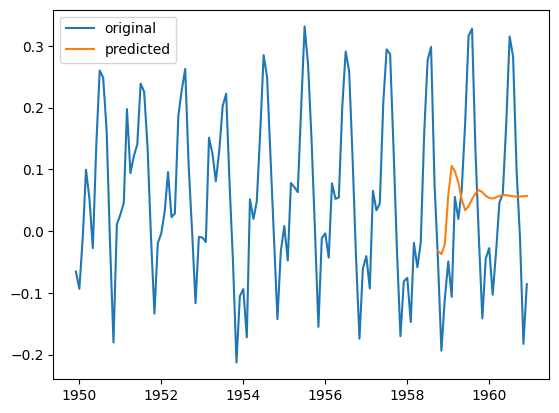

In [ ]:
ar = ARIMA(train, order = (4, 1, 0))
ar_result = ar.fit()

new_data['predict_ar'] = ar_result.predict(start = len(train), end= len(train)+len(test)-1, dynamic = False)

plt.plot(new_data['passengers'], label = 'original')
plt.plot(new_data['predict_ar'], label = 'predicted')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


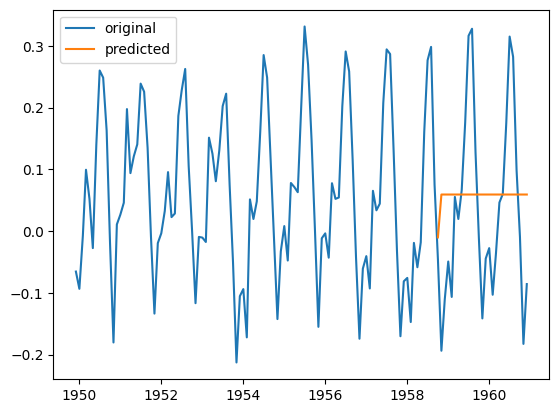

In [ ]:
ma = ARIMA(train, order = (0, 1, 2))
ma_result = ma.fit()

new_data['predict_ma'] = ma_result.predict(start = len(train), end= len(train)+len(test)-1, dynamic = False)

plt.plot(new_data['passengers'], label = 'original')
plt.plot(new_data['predict_ma'], label = 'predicted')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


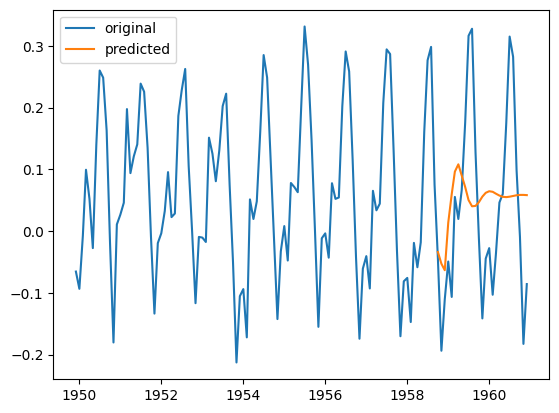

In [ ]:
arima = ARIMA(train, order = (4, 1, 2))
arima_result = arima.fit()

new_data['predict_arima'] = arima_result.predict(start = len(train), end= len(train)+len(test)-1, dynamic = False)

plt.plot(new_data['passengers'], label = 'original')
plt.plot(new_data['predict_arima'], label = 'predicted')
plt.legend()
plt.show()

In [ ]:
import itertools
from sklearn.metrics import *

p = range(0,8)
d = range(1,2)
q = range(0,8)

pdq = list(itertools.product(p,d,q))
rmse = []
order1 = []

for i in pdq:
  model = ARIMA(train, order = i)
  model_fit = model.fit()
  pred = model_fit.predict(start = len(train), end = len(train)+len(test)-1)
  error = np.sqrt(mean_squared_error(test, pred))
  order1.append(i)
  rmse.append(error)

results = pd.DataFrame(index = order1, data = rmse, columns = ['RMSE'])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
results.sort_values(by = "RMSE", ascending = True)

,RMSE
"(7, 1, 5)",0.068655
"(5, 1, 7)",0.071788
"(6, 1, 7)",0.073744
"(7, 1, 6)",0.075850
"(4, 1, 7)",0.076456
...,...
"(2, 1, 7)",0.149920
"(0, 1, 1)",0.150150
"(2, 1, 0)",0.151556
"(3, 1, 0)",0.151889


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


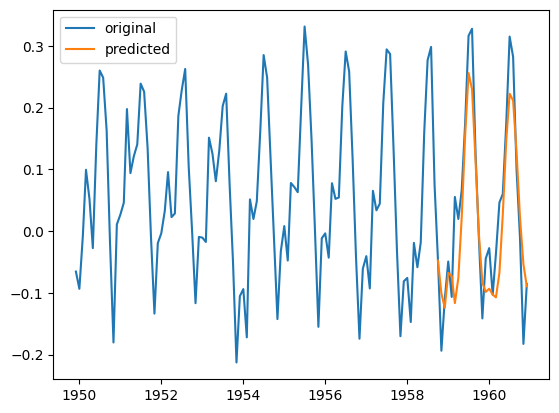

In [ ]:
arima_best = ARIMA(train, order = (7, 1, 5))
arima_result_best = arima_best.fit()

new_data['predict_arima_best'] = arima_result_best.predict(start = len(train), end= len(train)+len(test)-1, dynamic = False)

plt.plot(new_data['passengers'], label = 'original')
plt.plot(new_data['predict_arima_best'], label = 'predicted')
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


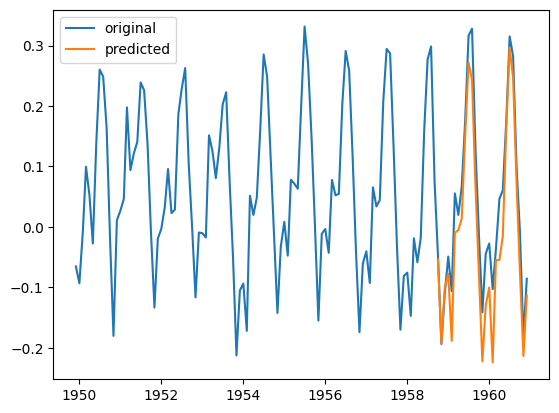

In [ ]:
sarima = SARIMAX(train, order = (7, 1, 5), seasonal_order = (7, 1, 5, 12))
sarima_result = sarima.fit()

new_data['predict_sarima_best'] = sarima_result.predict(start = len(train), end= len(train)+len(test)-1, dynamic = False)

plt.plot(new_data['passengers'], label = 'original')
plt.plot(new_data['predict_sarima_best'], label = 'predicted')
plt.legend()
plt.show()